# Semana 6: Mini-Proyecto Final

Esta evaluación tiene por propósito poner en práctica la identificación de tareas de visualización, la búsqueda de codificaciones, y la generación de codificaciones mediante programación. El siguiente archivo contiene un texto narrativo que informa detalles sobre un _dataset_ complejo y que busca apoyarse de visualizaciones para transmitir información.

En el documento se marcan las ubicaciones donde distintas codificaciones deben insertarse mediante celdas de código. 
Cada ubicación tiene además información que se provee sobre los datos y las tareas que buscan completar en dicha codificación.
En cada una de estas ubicaciones, debe: (1) identificar **una** tarea (una acción y un objetivo) utilizando los términos del *framework* revisado, (2) elegir **una** codificación gráfica acorde, de tal forma que ambas correspondan a la información dada, y (3) justificar en **un párrafo de máximo de 5 líneas** por qué la codificación elegida permite resolver la tarea identificada. Se proveen los datos necesarios para generar dichas codificaciones, y debes utilizar `pandas`, `matplotlib` y/o `seaborn` para generar las distintas visualizaciones.

El documento de respuesta y entrega es este mismo documento Jupyter Notebook. Debe completarse con:
1. El código de cada visualización con todas las celdas ejecutadas. Sólo es el código para **1 respuesta por visualización**. Si identifica más de una forma de realizar la visualización, **debe seleccionar una**. En caso de entregar más de 1 código por visualización, **se considera el primer código**.

<p></p>

2. **Una tarea (una acción y un objetivo)** identificada para cada visualización de la lista indicada en la clase ¿Por qué? En caso de responder más de una tarea, **se considera la primera entregada**.

    Recuerde que una tarea se compone de una acción y un objetivo. Las **acciones del _framework_ son:** presentar, descubrir, anotar, grabar, derivar, _lookup_, _browse_, _locate_, _explore_, identificar, comparar, resumir; y los objetivos deben ser extraídos del texto de cada caso. Algunos **ejemplos de objetivos son:** tendencia, outlier, features, distribución, extremos, dependencia, correlación, similaridad, etc.

<p></p>

3. **Un párrafo de máximo 5 líneas para justificar** cada gráfico en relación con **la tarea identificada**. Sólo se acepta la justificación acorde a **la tarea identificada (primera tarea entregada)** en el punto anterior. En caso de entregar justificaciones para otras tareas, estas no serán consideradas.


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## La gran pandemia

### Visualización 1

Durante el 2015 hubo una gran pandemia a nivel mundial. Luego de un año del descubrimiento del virus, se realizó un catastro de enfermos. Como es posible observar en el siguiente gráfico (que usted debe realizar), los resultados indicaron que los países más afectados fueron Francia, Japón y México, con más de 9.5 millones, 10.2 millones y 10.3 millones de contagiados, respectivamente. Incluso, se puede observar que México tuvo aproximadamente el doble de casos que Corea.

Para esta visualización, utilice los datos del archivo V01.csv

**Visualización 1 (V01)**

**Tarea identificada**: Presentar + Distribución.

**Visualización elegida**: Gráfico de barras horizontales.

**Justificación de la visualización**: Se pudo identificar que el dataset es tipo tabular con atributos categóricos y cuantitativos que buscan presentar como se distribuyeron la cantidad de contagios por cada país, tomando esto en cuenta se realizó una visualización con gráfico de barras horizontales con seaborn. Este gráfico es perfecto para visualizar comparaciones de cantidades de una manera directa y clara. Se recurrió al uso de una paleta de colores apta para todo publico, segun lo aprendido de https://colorbrewer2.org/#type=sequential&scheme=BuGn&n=3

In [4]:
# V01: Visualización que permita ver la cantidad total de infectados por país

v01 = pd.read_csv("V01.csv")
v01.head()

,Paises,Contagiados
0,España,569457
1,Chile,1088398
2,Guinea,1302202
3,Ecuador,1930001
4,Rusia,2000091


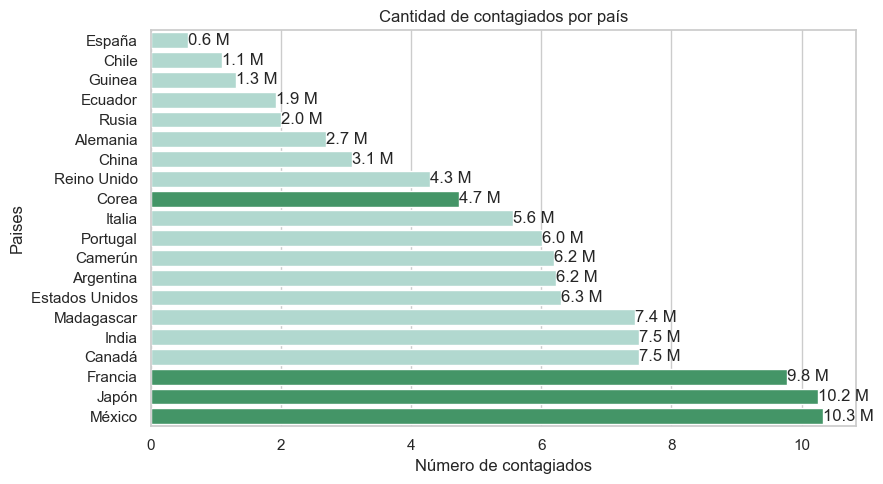

In [56]:
paises_destacados = ["Francia", "Japón", "México", "Corea"]

v01["Destacado"] = v01["Paises"].isin(paises_destacados)
v01["Contagiados_Millones"] = v01["Contagiados"] / 1_000_000

data=v01

sns.set_theme(style="whitegrid")

plt.figure(figsize=(9, 5))
ax=sns.barplot(
    data=v01,
    x="Contagiados_Millones",
    y="Paises",
    hue="Destacado",
    dodge=False, 
    palette="BuGn")

ax.legend_.remove()
plt.title("Cantidad de contagiados por país")
plt.xlabel("Número de contagiados")
plt.ylabel("Paises")

for patch in ax.patches:
    width = patch.get_width()
    y = patch.get_y() + patch.get_height() / 2

    if width > 0:
        ax.text(width, y, f"{width:.1f} M", va="center")

plt.tight_layout()
plt.show()


### Visualización 2

Explorando los datos históricos de esta pandemia, fue posible recopilar la información de la cantidad de contagiados internacionalmente (en todo el mundo) durante los primeros 5 años y los resultados mostraron un crecimiento exponencial de los casos.

Para esta visualización, utilice los datos del archivo V02.csv

**Visualización 2 (V02)**

**Tarea identificada**: Presentar + Tendencia

**Visualización elegida**: Gráfico de líneas.

**Justificación de la visualización**: Considerando que la tarea identificada es presentar la tendencia de contagios durante cinco años, se diseñó un gráfico de líneas, escalando la cantidad de contagios a millones y usando un marcador para resaltar cada cifra por año. Al ser un dataset pequeño se simplifica el contenido que desea mostrarse y facilita su comprensión.

In [57]:
# V02: Visualización que permita ver la evolución del total de infectados en el tiempo (fecha).

v02 = pd.read_csv("V02.csv")
v02.head()

,Año,Total Contagiados
0,2013,104778830
1,2014,168031244
2,2015,248136117
3,2016,372664870
4,2017,550371599


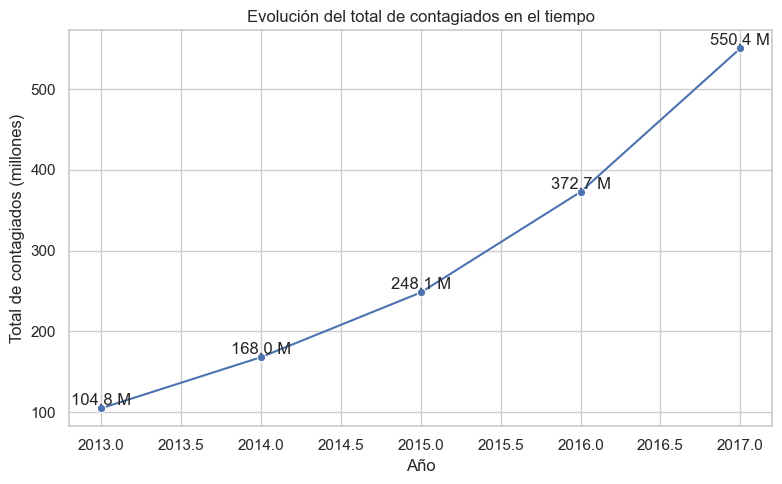

In [65]:
v02["Total_Millones"] = v02["Total Contagiados"] / 1_000_000
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 5))

sns.lineplot(data=v02, x="Año", y="Total_Millones", marker="o")

plt.title("Evolución del total de contagiados en el tiempo")
plt.xlabel("Año")
plt.ylabel("Total de contagiados (millones)")

ax = plt.gca()
for x, y in zip(v02["Año"], v02["Total_Millones"]):
    ax.text(x, y, f"{y:.1f} M", ha="center", va="bottom")

plt.tight_layout()
plt.show()

### Visualización 3

Ahora, comparando la situación por país, es posible notar cómo en algunos países, como Chile, la infección fue controlada mientras en otros no, como México. Esto se explica por la anticipada toma de decisiones en políticas de salud en varios de estos países.

Para esta visualización, utilice los datos del archivo V03.csv

**Visualización 3 (V03)**

**Tarea identificada**: Comparar + Tendendcias.

**Visualización elegida**: Gráfico de Lineas (small multiple)

**Justificación de la visualización**: Debido a que es necesario visualizar la tendencia de contagios por cada país y por cada año, se diseñó un small multiple de gráficos de línea, coloreando cada país para un efecto más diferenciador a simple vista (muy similar al mp2). Se realizó una preparación previa del dataset ejecutando la funcion .melt() de pandas: https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.melt.html#pandas.DataFrame.melt

In [66]:
# V03: Visualización que permita ver el total de infectados en el tiempo por país (fecha).

v03 = pd.read_csv("V03.csv")
v03.head()

,Pais,2013,2014,2015,2016,2017
0,Estados Unidos,6306611,12034284,21975254,30424000,60688631
1,España,569457,956750,1782312,2593025,3446904
2,Italia,5561888,8845776,16387430,16965989,18440429
3,Francia,9776457,13885349,16601864,25421972,46797459
4,Alemania,2692145,2600368,2507329,2417294,2326443


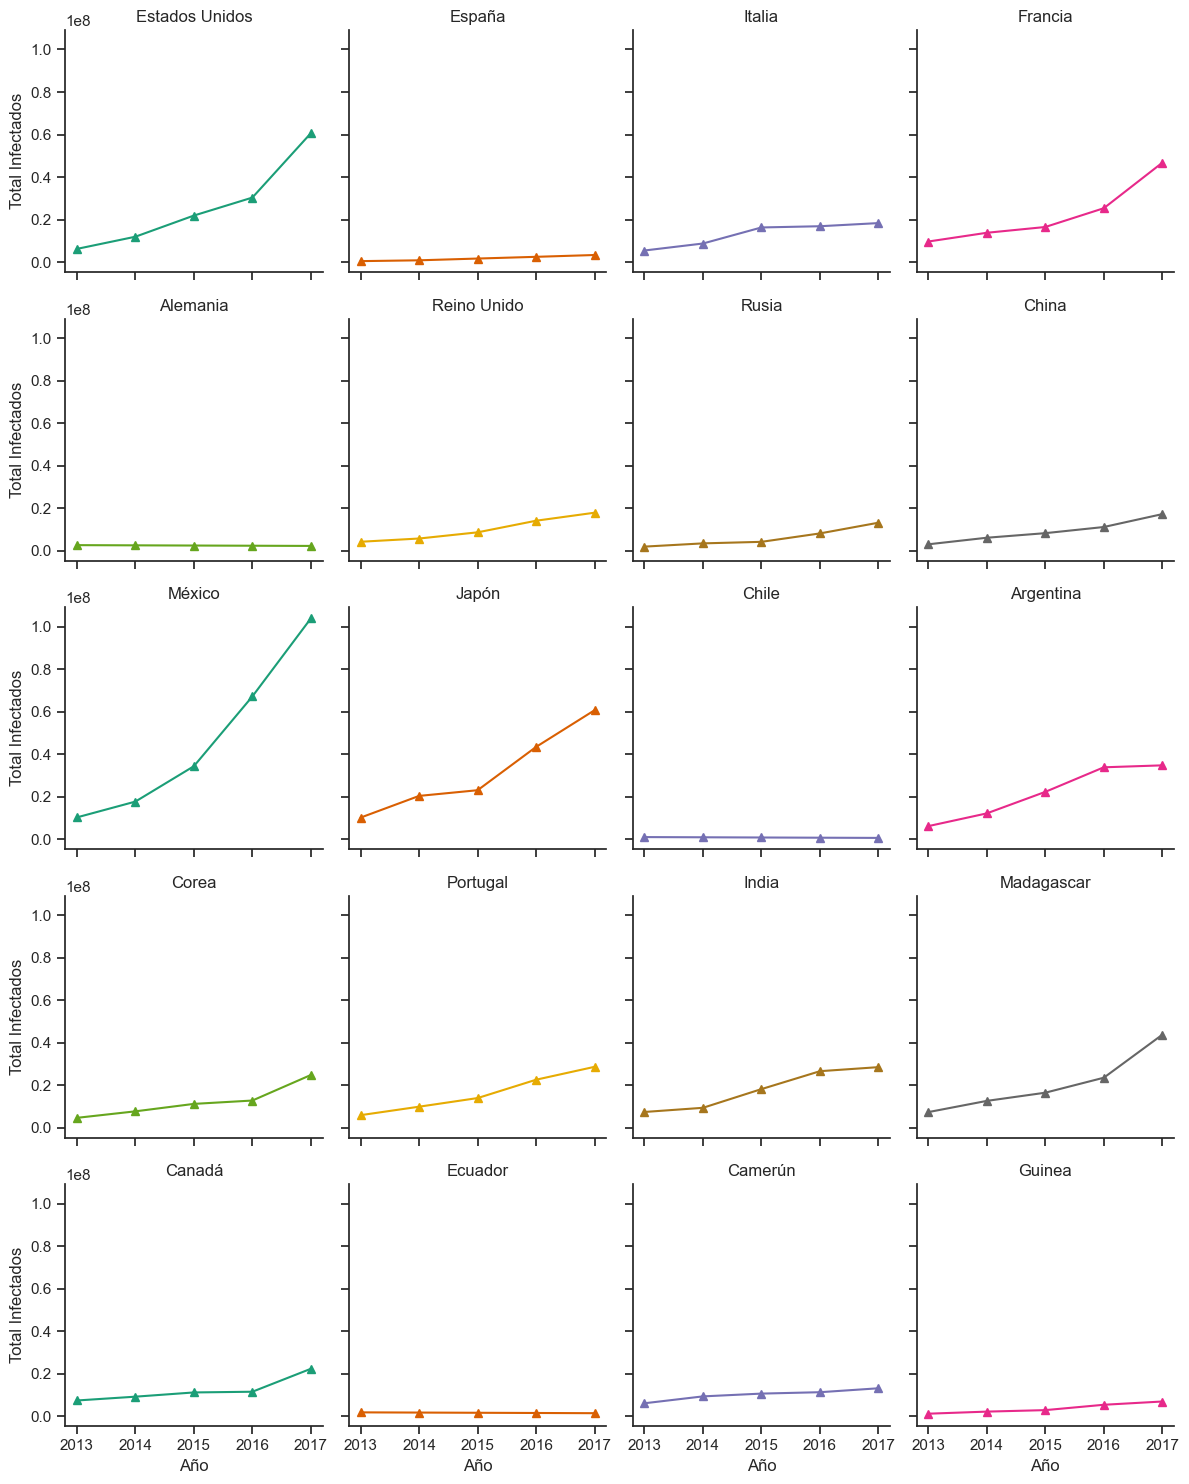

In [194]:
#Preparación previa del dataset con Pandas. De estrucutura ancha a alargada para lograr ejecutar correctamente la visualización.

v03_alargado = v03.melt(
    id_vars="Pais",
    var_name="Año",
    value_name="Total Infectados")

# Codigo de la visualización 

v03_alargado["Año"] = v03_alargado["Año"].astype(int)

grid = sns.FacetGrid(data=v03_alargado, col="Pais", col_wrap=4, hue="Pais", palette= "Dark2")
grid.map(plt.plot, "Año", "Total Infectados", marker="^")

grid.set_axis_labels("Año", "Total Infectados")
grid.set_titles(col_template="{col_name}")
plt.show()

### Visualización 4

Las visualizaciones anteriores colocan la evolución del contagios según las fechas de ocurrencia. No obstante, la realidad es que cada país tuvo su primer infectado en distintos momentos. Al encontrarse en distintas escalas de tiempo, surge la interrogante de cómo avanzó la distribución de contagios bajo una misma escala de tiempo, que corresponde al tiempo que lleva el país con infecciones presentes. 

Como ejemplo, observando el siguiente gráfico (que usted debe hacer), se encontró que:

1. Cuando los países llevaban dos meses de infección (`mes=2`), el mínimo de contagios presentes en el mundo fue en un país con aproximadamente 1000 casos, el máximo fue de aproximadamente 8000 casos, y la mediana a nivel mundial fue de 3000 casos aproximadamente. 

2. Cuando los países llevaban un año de infección (`mes=12`), el mínimo de contagios presentes en el mundo fue en un país con aproximadamente 1800 casos, el máximo fue de aproximadamente 10000 casos, y la mediana a nivel mundial fue de 4000 casos aproximadamente. 

3. Finalmente, fue posible apreciar que en el cuarto mes de contagio, hay 2 países que tuvieron una cantidad atípica de contagidas.

Para esta visualización, utilice los datos del archivo V04.csv

**Visualización 4 (V04)**

**Tarea identificada**: Explorar + Distribución.

**Visualización elegida**: Gráfico de caja.

**Justificación de la visualización**: El gráfico de cajas es perfecto para esta visualización porque toma la cantidad de contagios y permite representar en promedios como fue la distribución a nivel global por mes, además de mostrar los casos atípicos de una manera ordenada que se puede comprender visualmente.

In [97]:
# V04: Visualización que permite ver la distribución de número de contagios de países en función al tiempo de infección.

v04 = pd.read_csv("V04.csv")
v04.head()

,Pais,Mes,Contagiados
0,Estados Unidos,1,5230
1,Estados Unidos,2,4785
2,Estados Unidos,3,4217
3,Estados Unidos,4,704
4,Estados Unidos,5,8694


Text(0.5, 1.0, 'Distribución de contagios a nivel global por Mes')

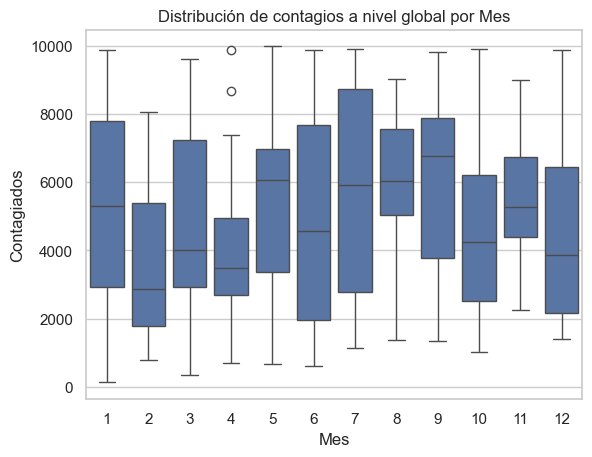

In [147]:
sns.boxplot(data=v04, x="Mes", y="Contagiados")
plt.title("Distribución de contagios a nivel global por Mes")

### Visualización 5

Otra interrogante que surgió fue ¿este virus fue más letal en épocas y lugares de bajas temperaturas, de altas temperaturas o la temperatura no tuvo efecto? En base a los datos reunidos de facellimientos registrados por mes en los 5 primeros años, fue posible observar lo siguiente para cada hemisferio:

Para esta visualización, utilice los datos de los archivos V05-hem-norte.csv y V05-hem-sur.csv

**Visualización 5 (V05)**

**Tarea identificada**: Identificar + Tendencia.

**Visualización elegida**: Gráfico de líneas.

**Justificación de la visualización**: Muy similar al caso dos, el próposito en esta visualización fue mostrar la tendencia a lo largo del tiempo, se optó por un gráfico de lineas donde cada año está representado por una línea de color distintivo al resto, lo que permite comparar el patron de contagios con cada año. Funcionando muy bien para la visualización de ambos hemisferios.

In [121]:
# V05: Dos visualizaciones (uno por hemisferio) que permita visualizar la cantidad de fallecimientos por mes y año. 
#      De modo que permita determinar si hubo algunos meses en particular donde aumentó la cantidad de fallecidos o
#      siempre se mantuvo de forma homogénea

v05n = pd.read_csv("V05-hem-norte.csv")
v05n.head()

,Año,Mes,Fallecidos
0,2013,01-Enero,243560
1,2013,02-Febrero,270623
2,2013,03-Marzo,284154
3,2013,04-Abril,213115
4,2013,05-Mayo,260474


In [117]:
v05s = pd.read_csv("V05-hem-sur.csv")
v05s.head()

,Año,Mes,Fallecidos
0,2013,07-Julio,243560
1,2013,08-Agosto,297685
2,2013,09-Septiembre,255738
3,2013,10-Octubre,202459
4,2013,11-Noviembre,260474


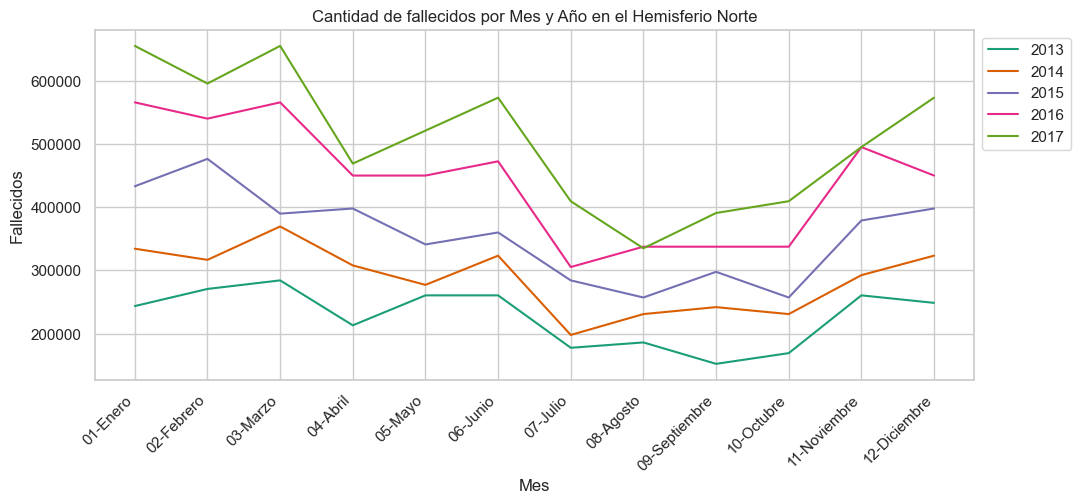

In [143]:
plt.figure(figsize=(10, 5))
sns.lineplot(data= v05n, x="Mes", y="Fallecidos", hue="Año", palette= "Dark2")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.title("Cantidad de fallecidos por Mes y Año en el Hemisferio Norte")

plt.legend(bbox_to_anchor=(1, 1))
plt.show()

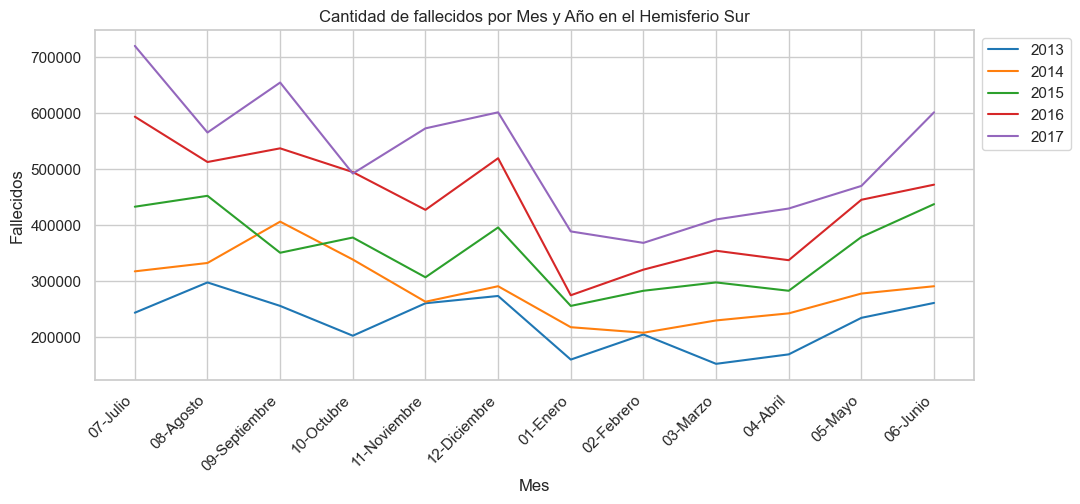

In [144]:
plt.figure(figsize=(10, 5))
sns.lineplot(data= v05s, x="Mes", y="Fallecidos", hue="Año", palette= "tab10")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.title("Cantidad de fallecidos por Mes y Año en el Hemisferio Sur")

plt.legend(bbox_to_anchor=(1, 1))
plt.show()

### Visualización 6

Por otro lado, esta pandemia que se caracterizó por una división etárea muy marcada entre sus contagiados. Cómo se observa en la visualización, el 60% de los contagiados eran personas sobre 50 años, 30% eran menores a los 18 años y solo el 10% restante oscila entre 19 y 49 años. Por otro lado, la segunda visualización muestra que el 80% presentaba como síntomas base: fiebre, tos y malestar estomacal; mientras que el 20% restante presentó síntomas extendidos a los anteriores, agregando dificultad para respirar. 

Para esta visualización, utilice los datos del archivo V06.csv

**Visualización 6 (V06)**

**Tarea identificada**: Presentar + Distribución.

**Visualización elegida**: Gráfico de torta.

**Justificación**: Considerando que el enunciado es bastante especifico en solicitar la visualización de atributos por catégoria y en porcentajes, el gráfico de tortas fue el seleccionado por representar de manera clara tal información, usando el tamaño de las áreas para transmitir la cantidad de porcentajes en cada visulaización.

In [164]:
# V06: Dos visualizaciones que permitan mostrar la proporción de infectados por edad 
#      y la proporción de síntomas posibles.
#      Hint: ambas visualizaciones son del mismo tipo.

v06 = pd.read_csv("V06.csv")
v06.head()

,Edad,Sintomas
0,>=50,base
1,>=50,base
2,>=50,base
3,>=50,base
4,>=50,base


In [163]:
infectados_edad = v06.groupby("Edad").size()
infectados_edad = infectados_edad/infectados_edad.sum()*100
infectados_edad

Edad
19-49    10.0
<=18     30.0
>=50     60.0
dtype: float64

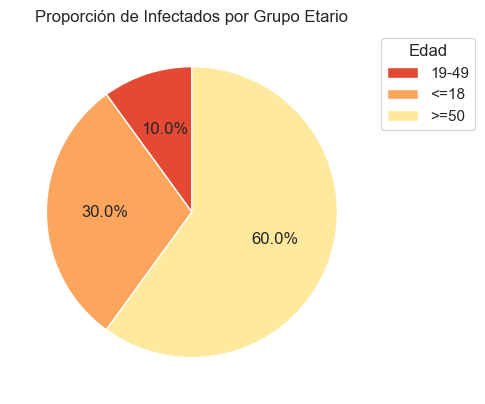

In [178]:
plt.figure(figsize=(5, 5))
plt.pie(infectados_edad, autopct= "%.1f%%", startangle=90, colors=sns.color_palette("RdYlBu"))
plt.title("Proporción de Infectados por Grupo Etario")
plt.legend(infectados_edad.index, title="Edad", bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

In [172]:
datos_sintomas = v06.groupby("Sintomas").size()
datos_sintomas = datos_sintomas/datos_sintomas.sum()*100
datos_sintomas

Sintomas
base         79.75
extendido    20.25
dtype: float64

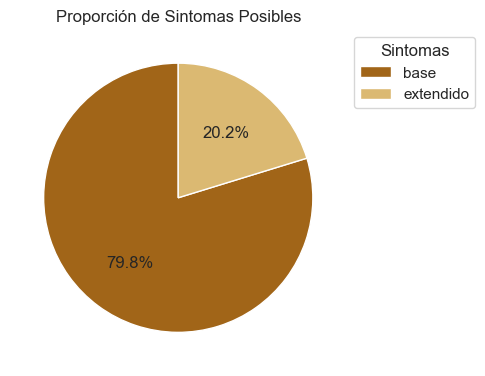

In [175]:
plt.figure(figsize=(5, 5))
plt.pie(datos_sintomas, autopct= "%.1f%%", startangle=90, colors=sns.color_palette("BrBG"))
plt.title("Proporción de Sintomas Posibles")
plt.legend(datos_sintomas.index, title="Sintomas", bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

### Visualización 7

Además de esta segmentación etarea y de diagnóstico, la investigación inicial no tenía una caracterización más profunda. Fue tras cruzar únicamente pares de atributos (peso vs edad, altura vs edad y altura vs peso) y analizar su correlación junto con una segmentación por tipo de síntomas, es que se logró obtener una mejor descripción de perfiles. Este cruce y análisis se evidencia en la siguiente visualización.

Para esta visualización, utilice los datos del archivo V07.csv

**Visualización 7 (V07)**

**Tarea identificada**: Descubrir  + Correlación.

**Visualización elegida**: Matriz de gráficos.

**Justificación**: Para lograr visualizar el cruce entre pares de atributos segmentando por tipo de sintomas, se diseñó una matriz de gráficos usando histogramas y diagramas de dispersión para analizar de forma simultánea la distribución de cada una así como la relación existente entre estos atributos.

In [179]:
# V07: Una visualización que permita apreciar distribución y potencialmente correlación entre 
#      pares de atributos de dataset: edad, peso y altura; con categorización por tipos de 
#      síntomas presentados.

v07 = pd.read_csv("V07.csv")
v07.head()

,Edad,Sintomas,Peso,Altura
0,70,base,72,155
1,71,base,61,161
2,83,base,66,179
3,77,base,63,190
4,76,base,80,164


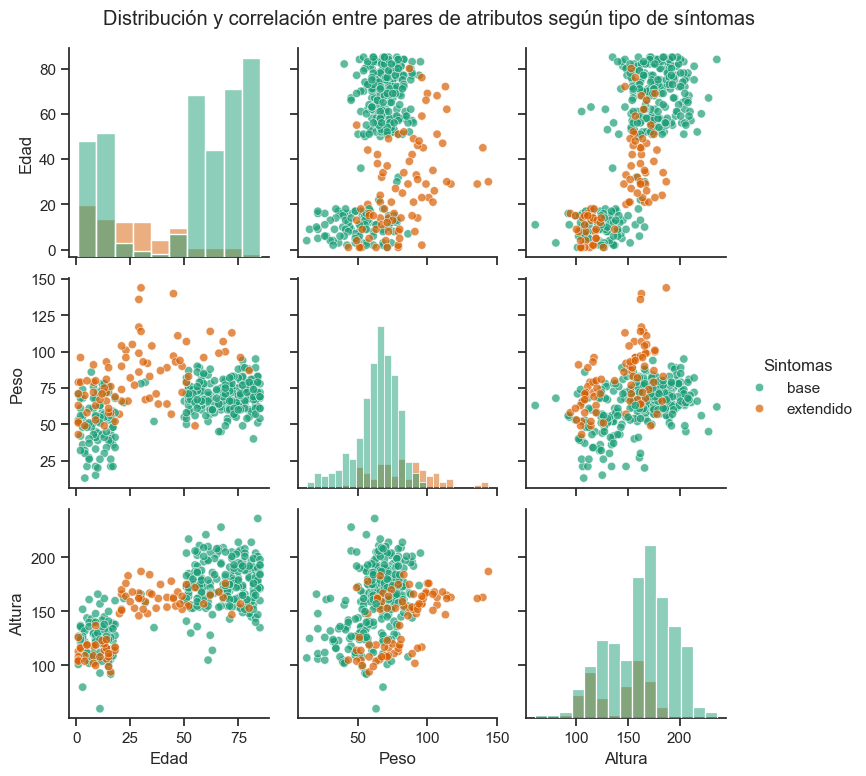

In [192]:
sns.set(style="ticks")

g = sns.pairplot(data=v07, vars=["Edad", "Peso", "Altura"], hue="Sintomas", palette="Dark2", diag_kind="hist", plot_kws={"alpha": 0.7})

g.fig.suptitle("Distribución y correlación entre pares de atributos según tipo de síntomas", y=1.03)
plt.show()